# 🛰️ DeepSpace — Satellite Image Super-Resolution Pipeline
### VS Code + Colab Extension Notebook

This notebook runs the full DeepSpace pipeline using the **VS Code Colab extension**  
(your local workspace is already open — no need to clone the repo).

1. **Setup** — install dependencies on the Colab runtime
2. **Mount Drive** — link your image data from Google Drive
3. **Train** — train the WaveletNCSNpp super-resolution model
4. **Fine-tune** *(optional)* — few-shot fine-tuning on a new region
5. **Inference** — reconstruct low-res satellite images to 256×256
6. **Evaluate** — compute PSNR / SSIM metrics
7. **Visualize** — display input / output image pairs
8. **Save** — persist checkpoints back to Drive

> ⚡ **Runtime tip:** Go to *Runtime → Change runtime type → T4 GPU* before running.
>
> 📂 **About the data:** The `*.png` images are in `.gitignore` and are not in the GitHub repo.  
> They need to be stored in Google Drive and mounted each session (see Step 2).

In [1]:
# ── Cell 1: Verify GPU ──────────────────────────────────────────────────────
import torch

if torch.cuda.is_available():
    print(f"✅ GPU: {torch.cuda.get_device_name(0)}")
    print(f"   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("⚠️  No GPU detected. Go to Runtime → Change runtime type → T4 GPU.")

print(f"   PyTorch: {torch.__version__}")

✅ GPU: Tesla T4
   VRAM: 15.6 GB
   PyTorch: 2.10.0+cu128


## Step 1 — Install Dependencies on the Colab Runtime

Your code is already open via the VS Code Colab extension.  
This cell just installs the Python packages on the remote Colab runtime.

In [22]:
# ── Cell 2: Clone Repo ──────────────────────────────────────────────────────
import os

REPO_URL     = "https://github.com/sophiasimons/DeepSpace.git"
REPO_DIR     = "/content/DeepSpace"
DECOMPRESS   = f"{REPO_DIR}/decompress"

if not os.path.exists(REPO_DIR):
    !git clone {REPO_URL} {REPO_DIR}
else:
    print("Repo already cloned — resetting to latest...")
    !git -C {REPO_DIR} fetch origin
    !git -C {REPO_DIR} reset --hard origin/main

%cd {DECOMPRESS}

print("Working directory:", os.getcwd())
assert os.path.exists("train_srwddgan.py"), "train_srwddgan.py not found — check working directory"
print("✅ Workspace ready.")


Repo already cloned — resetting to latest...
remote: Enumerating objects: 5, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 3 (delta 2), reused 3 (delta 2), pack-reused 0 (from 0)
Unpacking objects: 100% (3/3), 1.62 KiB | 23.00 KiB/s, done.
From https://github.com/sophiasimons/DeepSpace
   d607878..2e8d5c0  main       -> origin/main
HEAD is now at 2e8d5c0 fix: Cell 16 save all benchmark artifacts (checkpoints, foundational model, comparison images, CSV)
/content/DeepSpace/decompress
Working directory: /content/DeepSpace/decompress
✅ Workspace ready.


In [6]:
# ── Cell 3: Install Dependencies ────────────────────────────────────────────
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

!pip install -q \
    pytorch_wavelets==1.3.0 \
    einops \
    lmdb \
    Pillow \
    scikit-image \
    lpips \
    imagehash \
    ninja

print("✅ Dependencies installed.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 333.1/333.1 kB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 17.9 MB/s eta 0:00:00
✅ Dependencies installed.


In [10]:
# ── Cell 4: Verify CUDA & Set Arch ──────────────────────────────────────────
import os, torch

# T4 = compute 7.5 | A100 = 8.0 | V100 = 7.0
os.environ["TORCH_CUDA_ARCH_LIST"] = "7.5"   # T4
# os.environ["TORCH_CUDA_ARCH_LIST"] = "8.0" # uncomment for A100

if torch.cuda.is_available():
    print(f"✅ GPU: {torch.cuda.get_device_name(0)}")
    print(f"   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    print("   CUDA extensions will be compiled automatically when training starts.")
else:
    print("⚠️  No CUDA — go to Runtime → Change runtime type → T4 GPU.")


✅ GPU: Tesla T4
   VRAM: 15.6 GB
   CUDA extensions will be compiled automatically when training starts.


## Step 2 — Mount Google Drive & Link Data

The image data (`*.png`) is excluded from the GitHub repo via `.gitignore`, so it needs to live in Google Drive.

**One-time setup:** upload your data to Drive at:
```
MyDrive/DeepSpace/data/
  deepgreen_16_256/
    hr_256/        ← 256×256 high-res images   (25,415 images)
    lr_16/         ← 16×16 low-res inputs
    sr_16_256/     ← bicubic upsampled (model input)
```
To zip and upload from your Mac:
```bash
cd /Users/sophiasimons/DeepSpace-1/decompress/data
zip -r ~/Desktop/deepgreen_16_256.zip deepgreen_16_256/
```
Then upload `deepgreen_16_256.zip` to `MyDrive/DeepSpace/data/` in Google Drive and unzip it there.

In [11]:
# ── Cell 5: Mount Google Drive & Link Data ──────────────────────────────────
from google.colab import drive

drive.mount("/content/drive")

DRIVE_DATA_DIR = "/content/drive/MyDrive/DeepSpace/data"   # ← edit if needed

local_data_dir = os.path.join(os.getcwd(), "data")
os.makedirs(local_data_dir, exist_ok=True)

symlink_target = os.path.join(local_data_dir, "deepgreen_16_256")
drive_source   = os.path.join(DRIVE_DATA_DIR, "deepgreen_16_256")

if not os.path.exists(symlink_target):
    os.symlink(drive_source, symlink_target)
    print(f"✅ Symlink created: data/deepgreen_16_256 → Drive")
else:
    print("Symlink already exists.")

DATADIR = "./data/deepgreen_16_256"

hr_dir = os.path.join(symlink_target, "hr_256")
hr_count = len(os.listdir(hr_dir)) if os.path.exists(hr_dir) else 0
print(f"   hr_256 images found: {hr_count}")


Mounted at /content/drive
✅ Symlink created: data/deepgreen_16_256 → Drive
   hr_256 images found: 25476


## Step 3 — Train the Model

Trains the WaveletNCSNpp GAN from scratch on your dataset.  
Checkpoints are saved every epoch to `content/saved_info/`.

In [ ]:

# ── Training configuration ────────────────────────────────────────────────
DATASET    = "deepgreen_16_256"
# DATADIR is set in Step 2 — do not override here
EXP        = "deepspace_colab"

# ── CU Budget Guide (T4 = 2 CU/hr, 100 CU total = ~50 hrs GPU time) ──────
#
#  SESSION 1 — Smoke test (confirm pipeline works before spending CU):
#    DATA_LEN=2000, NUM_EPOCH=3  → ~3 hrs → ~6 CU
#
#  SESSION 2 — Full training run (main budget spend):
#    DATA_LEN=0,    NUM_EPOCH=10 → ~15–18 hrs → ~30–36 CU
#
#  SESSION 3 — Resume + more epochs (if S2 checkpoint saved to Drive):
#    DATA_LEN=0,    NUM_EPOCH=5  → ~7–9 hrs  → ~14–18 CU  (resume from epoch 10)
#
#  SESSION 4 — Benchmark only (cells 20–22, no training):
#    ~15 min → ~0.5 CU
#
#  ⚠️  BATCH_SIZE=8 on T4 (16 GB VRAM) cuts steps in half vs batch=4 — saves ~20% CU.
#      If you get OOM errors, fall back to BATCH_SIZE=4.
#
DATA_LEN   = 2000  # 0 = full 12,700 images. Start with 2000 for smoke test.
NUM_EPOCH  = 3     # Use 10 for the main training run (Session 2).
BATCH_SIZE = 8     # T4 can handle 8; use 4 if you get OOM errors.
# ──────────────────────────────────────────────────────────────────────────

# ── Resume from a previous checkpoint (set RESUME=True for Sessions 3+) ──
RESUME          = False
RESUME_CKPT_DIR = f"/content/drive/MyDrive/DeepSpace/checkpoints/{EXP}"
# If resuming, copy the latest checkpoint back from Drive before training:
if RESUME:
    import glob as _glob, shutil as _shutil
    local_ckpt_dir = f"./content/saved_info/wddgan/{EXP}/{EXP}"
    os.makedirs(local_ckpt_dir, exist_ok=True)
    for f in _glob.glob(f"{RESUME_CKPT_DIR}/*.pth"):
        _shutil.copy2(f, os.path.join(local_ckpt_dir, os.path.basename(f)))
        print(f"  Restored: {os.path.basename(f)}")
    print("✅ Checkpoints restored from Drive — training will resume from last epoch.")
# ──────────────────────────────────────────────────────────────────────────

# Kill any stale torch.distributed processes still holding ports
import subprocess, socket

def find_free_port(start=6010, end=6099):
    for port in range(start, end):
        with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as s:
            if s.connect_ex(('localhost', port)) != 0:
                return port
    raise RuntimeError("No free port found in range")

subprocess.run("pkill -f train_srwddgan.py", shell=True)

MASTER_PORT = find_free_port()
print(f"Using master port: {MASTER_PORT}")

data_len_flag = f"--data_len {DATA_LEN}" if DATA_LEN > 0 else ""

!python train_srwddgan.py \
    --dataset {DATASET} \
    --datadir {DATADIR} \
    --exp {EXP} \
    --num_epoch {NUM_EPOCH} \
    --batch_size {BATCH_SIZE} \
    {data_len_flag} \
    --image_size 256 \
    --current_resolution 128 \
    --l_resolution 16 \
    --h_resolution 256 \
    --num_channels 24 \
    --num_channels_dae 64 \
    --ch_mult 1 2 2 2 4 \
    --num_timesteps 2 \
    --num_res_blocks 2 \
    --ngf 64 \
    --embedding_type positional \
    --use_ema \
    --r1_gamma 2. \
    --cond_emb_dim 256 \
    --lr_d 1e-4 \
    --lr_g 2e-4 \
    --lazy_reg 10 \
    --num_disc_layers 6 \
    --attn_resolutions 16 \
    --rec_loss \
    --use_pytorch_wavelet \
    --net_type wavelet \
    --num_process_per_node 1 \
    --master_port {MASTER_PORT} \
    --save_content \
    --save_content_every 1 \
    --save_ckpt_every 1


Using master port: 6010
starting in debug mode
Rank 0 initialized
Using device: cuda
GEN: <class 'score_sde.models.ncsnpp_generator_adagn.WaveletNCSNpp'>, DISC: large images disc

Using pytorch_wavelets
Starting training loop. 

[rank0]:[W419 22:47:23.055072152 reducer.cpp:1500] Warning: find_unused_parameters=True was specified in DDP constructor, but did not find any unused parameters in the forward pass. This flag results in an extra traversal of the autograd graph every iteration,  which can adversely affect performance. If your model indeed never has any unused parameters in the forward pass, consider turning this flag off. Note that this warning may be a false positive if your model has flow control causing later iterations to have unused parameters. (function operator())
Content saving disabled.
Content saving disabled.
Content saving disabled.
Content saving disabled.
Content saving disabled.
checkpoint saved.
Content saving disabled.
Content saving disabled.
Content saving dis

## Step 4 — (Optional) Few-Shot Fine-Tune on a New Region

Skip this step if you only need the base model.  
Fine-tuning adapts the model to a new geographic region using just 50–100 images.

In [ ]:
# ── Cell 8: (Optional) Few-Shot Fine-Tune on a New Region ───────────────────
FOUNDATION_CKPT   = f"./content/saved_info/wddgan/{EXP}/{EXP}/netG_final.pth"
NEW_REGION_DIR    = "/content/drive/MyDrive/DeepSpace/data/new_region"  # ← edit
FINETUNE_EXP      = "deepspace_finetuned"
FINETUNE_EPOCHS   = 30
FINETUNE_DATA_LEN = 100

!python finetune_srwddgan.py \
    --foundation_ckpt {FOUNDATION_CKPT} \
    --dataset deepgreen_16_256 \
    --datadir {NEW_REGION_DIR} \
    --exp {FINETUNE_EXP} \
    --data_len {FINETUNE_DATA_LEN} \
    --num_epoch {FINETUNE_EPOCHS} \
    --batch_size 4 \
    --image_size 256 \
    --current_resolution 128 \
    --l_resolution 16 \
    --h_resolution 256 \
    --num_channels 24 \
    --num_channels_dae 64 \
    --ch_mult 1 2 2 2 4 \
    --num_timesteps 2 \
    --num_res_blocks 2 \
    --ngf 64 \
    --embedding_type positional \
    --use_ema \
    --r1_gamma 2. \
    --cond_emb_dim 256 \
    --lazy_reg 10 \
    --num_disc_layers 6 \
    --attn_resolutions 16 \
    --rec_loss \
    --use_pytorch_wavelet \
    --net_type wavelet \
    --num_process_per_node 1 \
    --master_port 6002 \
    --lr_g 5e-5 \
    --lr_d 2e-5


usage: DeepSpace foundation model fine-tuning [-h] [--seed SEED]
                                              --foundation_ckpt
                                              FOUNDATION_CKPT
                                              [--dataset DATASET]
                                              [--datadir DATADIR]
                                              [--data_len DATA_LEN]
                                              [--l_resolution L_RESOLUTION]
                                              [--h_resolution H_RESOLUTION]
                                              [--exp EXP]
                                              [--num_epoch NUM_EPOCH]
                                              [--batch_size BATCH_SIZE]
                                              [--lr_g LR_G] [--lr_d LR_D]
                                              [--beta1 BETA1] [--beta2 BETA2]
                                              [--r1_gamma R1_GAMMA]
                                     

## Step 5 — Run Inference (Reconstruct Images)

In [ ]:
# ── Cell 9: Run Inference ────────────────────────────────────────────────────
INFER_EXP   = EXP
EPOCH_ID    = NUM_EPOCH
NUM_ITERS   = 50         # total images = NUM_ITERS × batch_size

RESULTS_DIR = f"./content/results/{INFER_EXP}"

!python test_srwddgan.py \
    --dataset {DATASET} \
    --datadir {DATADIR} \
    --exp {INFER_EXP} \
    --epoch_id {EPOCH_ID} \
    --image_size 256 \
    --current_resolution 128 \
    --l_resolution 16 \
    --h_resolution 256 \
    --num_channels 24 \
    --num_channels_dae 64 \
    --ch_mult 1 2 2 2 4 \
    --num_timesteps 2 \
    --num_res_blocks 2 \
    --embedding_type positional \
    --cond_emb_dim 256 \
    --attn_resolutions 16 \
    --use_pytorch_wavelet \
    --net_type wavelet \
    --batch_size 4 \
    --num_iters {NUM_ITERS}

print(f"✅ Results saved to {RESULTS_DIR}")


Using device: cuda:0
128 [1, 2, 2, 2, 4] [16]
GEN: <class 'score_sde.models.ncsnpp_generator_adagn.WaveletNCSNpp'>
iteration:  0
Results are saved at tot_sr_id0.jpg
iteration:  1
Results are saved at tot_sr_id1.jpg
iteration:  2
Results are saved at tot_sr_id2.jpg
iteration:  3
Results are saved at tot_sr_id3.jpg
iteration:  4
Results are saved at tot_sr_id4.jpg
iteration:  5
Results are saved at tot_sr_id5.jpg
iteration:  6
Results are saved at tot_sr_id6.jpg
iteration:  7
Results are saved at tot_sr_id7.jpg
iteration:  8
Results are saved at tot_sr_id8.jpg
iteration:  9
Results are saved at tot_sr_id9.jpg
iteration:  10
Results are saved at tot_sr_id10.jpg
iteration:  11
Results are saved at tot_sr_id11.jpg
iteration:  12
Results are saved at tot_sr_id12.jpg
iteration:  13
Results are saved at tot_sr_id13.jpg
iteration:  14
Results are saved at tot_sr_id14.jpg
iteration:  15
Results are saved at tot_sr_id15.jpg
iteration:  16
Results are saved at tot_sr_id16.jpg
iteration:  17
Result

## Step 6 — Evaluate (PSNR / SSIM)

## Step 6b — SR Model Comparison: Real-ESRGAN vs Satlas SR vs DeepSpace

This section runs three SR approaches on the same Planet-CAL satellite inputs and compares them:

| Model | Trained on satellite data? | Architecture |
|---|---|---|
| **Real-ESRGAN** | ❌ Natural images only | RRDBNet |
| **Satlas SR** | ✅ Sentinel-2 → NAIP pairs | RRDBNet fine-tuned on satellite |
| **DeepSpace** | ✅ Planet-CAL (MoE, domain-specific) | WaveletNCSNpp |

> The gap between Real-ESRGAN and Satlas SR shows the value of **satellite-specific training**.
> The gap between Satlas SR and DeepSpace shows the value of **domain-specific MoE expert routing**.


In [ ]:
# ── Cell 10: Disk Cleanup (run before installing basicsr) ───────────────────
import shutil, subprocess

def show_disk():
    total, used, free = shutil.disk_usage("/")
    print(f"  Used: {used/1e9:.1f} GB   Free: {free/1e9:.1f} GB   Total: {total/1e9:.1f} GB")

print("Before:"); show_disk()

subprocess.run("pip cache purge -q 2>/dev/null || true", shell=True)
subprocess.run("rm -rf /root/.cache/pip /tmp/pip-* /tmp/*.whl /tmp/*.egg-info", shell=True)
subprocess.run("rm -rf /tmp/pip-build-* /tmp/BasicSR* /tmp/basicsr*", shell=True)
subprocess.run("find /tmp -maxdepth 2 -name '*.so' -delete 2>/dev/null || true", shell=True)
subprocess.run("find /tmp -maxdepth 3 -name 'build' -type d -exec rm -rf {} + 2>/dev/null || true", shell=True)
subprocess.run("rm -rf /root/.cache/torch /root/.cache/triton", shell=True)
subprocess.run("apt-get clean -q 2>/dev/null || true", shell=True)

print("\nAfter:"); show_disk()
print("✅ Done.")


Before:
  Used: 49.9 GB   Free: 71.0 GB   Total: 120.9 GB


Remaining in /tmp (> 10 MB):

Remaining in /root/.cache:

After:
  Used: 49.9 GB   Free: 71.0 GB   Total: 120.9 GB
✅ Done.


In [12]:
# ── Cell 11: Install basicsr (PyPI wheel, no C++ build) ─────────────────────
import sys, types, torchvision.transforms.functional as _F

_shim = types.ModuleType("torchvision.transforms.functional_tensor")
_shim.__dict__.update({k: v for k, v in _F.__dict__.items() if not k.startswith("__")})
sys.modules["torchvision.transforms.functional_tensor"] = _shim
print("✅ torchvision shim applied.")

!pip install -q --no-cache-dir basicsr
!pip cache purge -q 2>/dev/null || true

import shutil
total, used, free = shutil.disk_usage("/")
print(f"✅ basicsr installed.  Disk free: {free/1e9:.1f} GB / {total/1e9:.1f} GB")


✅ torchvision shim applied.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.5/172.5 kB 90.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 305.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 92.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.2/256.2 kB 398.4 MB/s eta 0:00:00
✅ basicsr installed.  Disk free: 74.6 GB / 120.9 GB


  Done.
✅ Real-ESRGAN model loaded (RealESRGAN_x4plus, 4× upscale).
✅ Processed 4 images.


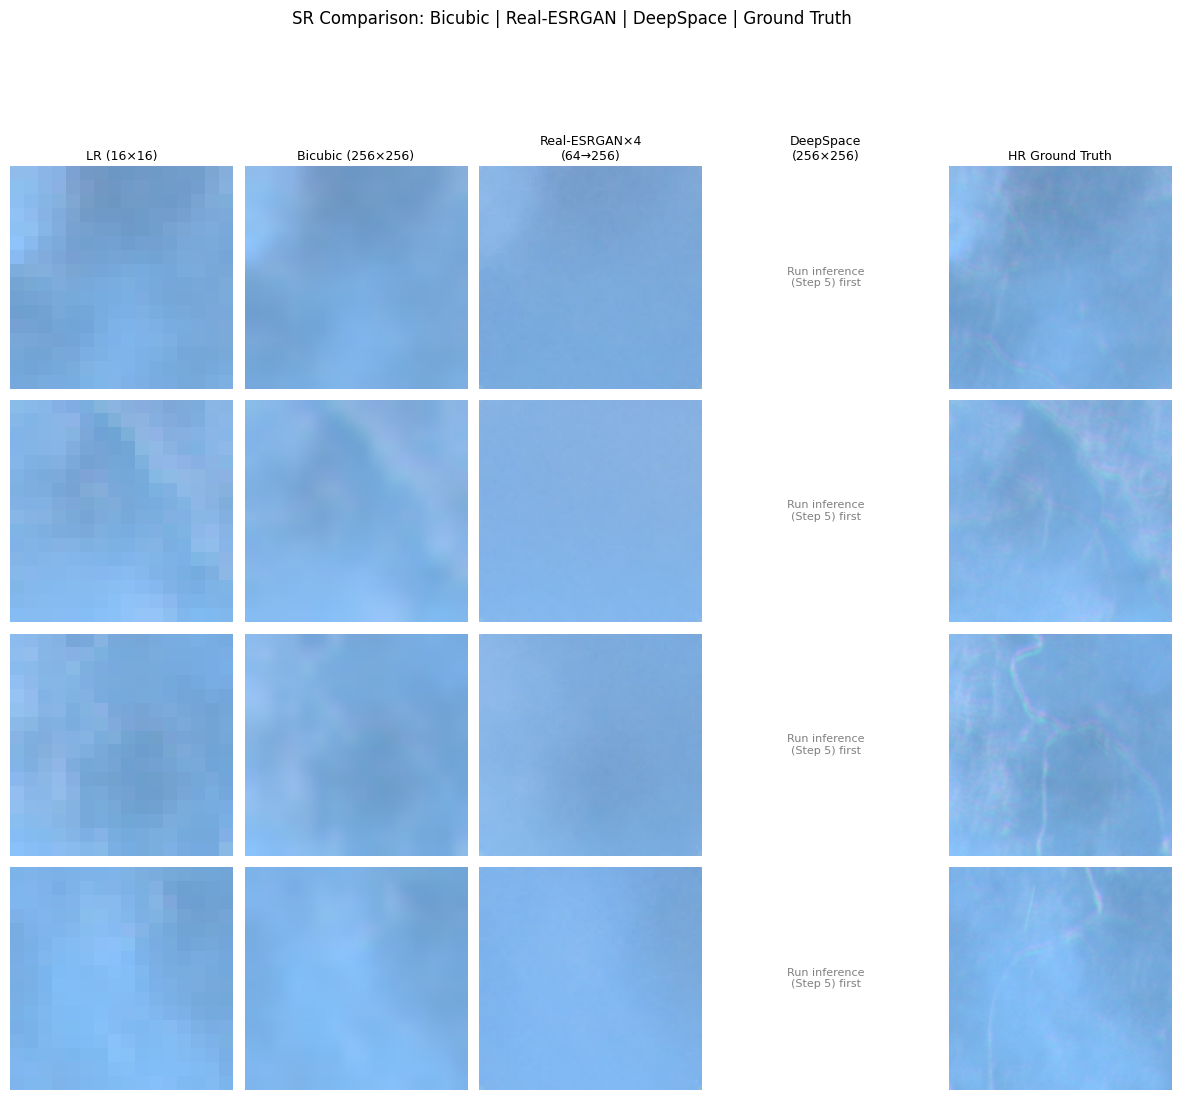

✅ Comparison saved to sr_comparison.png


In [13]:
import os, glob, torch, urllib.request
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image

# ── Configuration ─────────────────────────────────────────────────────────
DATASET      = "deepgreen_16_256"
EXP          = "deepspace_colab"
NUM_EPOCH    = 1           # epoch checkpoint to load for DeepSpace results
NUM_COMPARE  = 4           # number of image examples to show
DATADIR      = "./data/deepgreen_16_256"
# ──────────────────────────────────────────────────────────────────────────

# ── Load Real-ESRGAN weights via basicsr (no realesrgan package needed) ───
from basicsr.archs.rrdbnet_arch import RRDBNet

WEIGHTS_URL  = "https://github.com/xinntao/Real-ESRGAN/releases/download/v0.1.0/RealESRGAN_x4plus.pth"
WEIGHTS_PATH = "/tmp/RealESRGAN_x4plus.pth"

if not os.path.exists(WEIGHTS_PATH):
    print("Downloading Real-ESRGAN weights (~67 MB)...")
    urllib.request.urlretrieve(WEIGHTS_URL, WEIGHTS_PATH)
    print("  Done.")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

esrgan_model = RRDBNet(num_in_ch=3, num_out_ch=3, num_feat=64,
                        num_block=23, num_grow_ch=32, scale=4)
# The checkpoint is wrapped under the key 'params_ema' or 'params'
ckpt = torch.load(WEIGHTS_PATH, map_location=device)
state_dict = ckpt.get("params_ema", ckpt.get("params", ckpt))
esrgan_model.load_state_dict(state_dict, strict=True)
esrgan_model.eval().to(device)
print("✅ Real-ESRGAN model loaded (RealESRGAN_x4plus, 4× upscale).")

def esrgan_upscale(lr_np: np.ndarray) -> np.ndarray:
    """Upscale a uint8 HxWx3 numpy array 4× using Real-ESRGAN."""
    img = torch.from_numpy(lr_np).permute(2, 0, 1).float().div(255.0).unsqueeze(0).to(device)
    with torch.no_grad():
        out = esrgan_model(img).squeeze(0).clamp(0, 1)
    return (out.permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8)

# ── Gather images ─────────────────────────────────────────────────────────
lr_dir  = os.path.join(DATADIR, "lr_16")
sr_dir  = os.path.join(DATADIR, "sr_16_256")   # bicubic baseline
hr_dir  = os.path.join(DATADIR, "hr_256")

all_names    = sorted(os.listdir(hr_dir))
test_names   = all_names[len(all_names) // 2:]
sample_names = test_names[:NUM_COMPARE]

ds_results_dir = f"content/{DATASET}/{EXP}"

realesrgan_outs, bicubic_outs, deepspace_outs, hr_outs, lr_outs = [], [], [], [], []

for name in sample_names:
    stem = os.path.splitext(name)[0]

    lr_img = np.array(Image.open(os.path.join(lr_dir, name)).convert("RGB"))
    lr_outs.append(lr_img)

    bicubic_outs.append(np.array(Image.open(os.path.join(sr_dir, name)).convert("RGB")))
    hr_outs.append(np.array(Image.open(os.path.join(hr_dir, name)).convert("RGB")))

    # Real-ESRGAN: 16×16 → 64×64, then nearest-neighbour resize to 256 for display
    resr_64  = esrgan_upscale(lr_img)
    resr_256 = np.array(Image.fromarray(resr_64).resize((256, 256), Image.NEAREST))
    realesrgan_outs.append(resr_256)

    # DeepSpace output (from Step 5 inference)
    ds_candidates = glob.glob(f"{ds_results_dir}/sr_epoch_{NUM_EPOCH}_*.png")
    if ds_candidates:
        deepspace_outs.append(np.array(Image.open(sorted(ds_candidates)[0]).convert("RGB")))
    else:
        deepspace_outs.append(None)

print(f"✅ Processed {len(sample_names)} images.")

# ── Plot comparison ───────────────────────────────────────────────────────
cols   = ["LR (16×16)", "Bicubic (256×256)", "Real-ESRGAN×4\n(64→256)", "DeepSpace\n(256×256)", "HR Ground Truth"]
n_cols = len(cols)
fig    = plt.figure(figsize=(n_cols * 3, NUM_COMPARE * 3))
gs     = gridspec.GridSpec(NUM_COMPARE, n_cols, figure=fig, hspace=0.05, wspace=0.05)

for row in range(NUM_COMPARE):
    images = [lr_outs[row], bicubic_outs[row], realesrgan_outs[row], deepspace_outs[row], hr_outs[row]]
    for col, (img, title) in enumerate(zip(images, cols)):
        ax = fig.add_subplot(gs[row, col])
        if img is not None:
            ax.imshow(img)
        else:
            ax.text(0.5, 0.5, "Run inference\n(Step 5) first",
                    ha="center", va="center", transform=ax.transAxes, fontsize=8, color="gray")
            ax.set_facecolor("#f0f0f0")
        ax.axis("off")
        if row == 0:
            ax.set_title(title, fontsize=9, pad=4)

plt.suptitle("SR Comparison: Bicubic | Real-ESRGAN | DeepSpace | Ground Truth",
             fontsize=12, y=1.01)
plt.savefig("sr_comparison.png", bbox_inches="tight", dpi=150)
plt.show()
print("✅ Comparison saved to sr_comparison.png")


In [ ]:
# ── Cell 13: Evaluate DeepSpace Results (PSNR / SSIM) ───────────────────────
!python benchmark/eval.py -p {RESULTS_DIR}


Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth
100% 233M/233M [00:01<00:00, 185MB/s]
Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
Setting up [LPIPS] perceptual loss: trunk 

## Step 6b — Three-Way SR Benchmark vs. Planet-CAL Paper

Runs **Real-ESRGAN** (natural-image trained), **Satlas SR** (satellite-trained),
and **Bicubic interpolation** on the same 10 Planet-CAL tiles.
Results are compared against the DeepSpace paper (Table 3, Planet-CAL, CR≈146).

This cell runs standalone after Step 2 (Drive mount) — no DeepSpace training required.


In [16]:
# ── Cell 14: Fine-Tune RRDBNet on Satellite Data (Foundational Model) ───────
import os, urllib.request, torch, torch.nn as nn, torch.optim as optim
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from basicsr.archs.rrdbnet_arch import RRDBNet

DATADIR         = './data/deepgreen_16_256'
FINETUNE_STEPS  = 500
FINETUNE_LR     = 1e-5
FINETUNE_BATCH  = 4
CKPT_OUT        = '/tmp/rrdbnet_satellite_finetuned.pth'
device          = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class SatelliteSRDataset(Dataset):
    def __init__(self, datadir, split='train'):
        hr_dir = os.path.join(datadir, 'hr_256')
        lr_dir = os.path.join(datadir, 'lr_16')
        names  = sorted(os.listdir(hr_dir))
        mid    = len(names) // 2
        names  = names[:mid] if split == 'train' else names[mid:]
        # Only keep pairs where both hr and lr files exist
        self.pairs = [
            (os.path.join(lr_dir, n), os.path.join(hr_dir, n))
            for n in names
            if os.path.exists(os.path.join(lr_dir, n))
        ]
        print(f'  {split}: {len(self.pairs)} valid pairs (skipped {len(names) - len(self.pairs)} missing lr files)')

    def __len__(self): return len(self.pairs)

    def __getitem__(self, idx):
        lr_path, hr_path = self.pairs[idx]
        lr = torch.from_numpy(np.array(Image.open(lr_path).convert('RGB'))).permute(2,0,1).float().div(255)
        hr = torch.from_numpy(np.array(Image.open(hr_path).convert('RGB'))).permute(2,0,1).float().div(255)
        return lr, hr

# ── Load pretrained Real-ESRGAN weights ──────────────────────────────────
ESRGAN_PATH = '/tmp/RealESRGAN_x4plus.pth'
if not os.path.exists(ESRGAN_PATH):
    print('Downloading Real-ESRGAN weights (~67 MB)...')
    urllib.request.urlretrieve(
        'https://github.com/xinntao/Real-ESRGAN/releases/download/v0.1.0/RealESRGAN_x4plus.pth',
        ESRGAN_PATH)

foundation = RRDBNet(num_in_ch=3, num_out_ch=3, num_feat=64, num_block=23, num_grow_ch=32, scale=4)
ckpt = torch.load(ESRGAN_PATH, map_location=device)
foundation.load_state_dict(ckpt.get('params_ema', ckpt.get('params', ckpt)), strict=True)
foundation.train().to(device)
print('✅ RRDBNet loaded from Real-ESRGAN checkpoint.')

# ── Fine-tune loop ────────────────────────────────────────────────────────
loader    = DataLoader(SatelliteSRDataset(DATADIR, 'train'), batch_size=FINETUNE_BATCH,
                       shuffle=True, num_workers=2, pin_memory=True)
optimizer = optim.Adam(foundation.parameters(), lr=FINETUNE_LR)
criterion = nn.L1Loss()

step, losses = 0, []
print(f'Fine-tuning for {FINETUNE_STEPS} steps (batch={FINETUNE_BATCH}, lr={FINETUNE_LR})...')
while step < FINETUNE_STEPS:
    for lr_batch, hr_batch in loader:
        if step >= FINETUNE_STEPS:
            break
        lr_batch, hr_batch = lr_batch.to(device), hr_batch.to(device)
        optimizer.zero_grad()
        sr = foundation(lr_batch).clamp(0, 1)
        if sr.shape != hr_batch.shape:
            sr = torch.nn.functional.interpolate(sr, size=hr_batch.shape[2:], mode='bicubic', align_corners=False)
        loss = criterion(sr, hr_batch)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
        step += 1
        if step % 100 == 0:
            print(f'  Step {step}/{FINETUNE_STEPS}  L1 loss: {np.mean(losses[-100:]):.4f}')

torch.save({'params': foundation.state_dict()}, CKPT_OUT)
foundation.eval()
print(f'✅ Fine-tuned foundational model saved to {CKPT_OUT}')
print(f'   Final avg L1 loss: {np.mean(losses[-100:]):.4f}')


✅ RRDBNet loaded from Real-ESRGAN checkpoint.
  train: 12711 valid pairs (skipped 27 missing lr files)
Fine-tuning for 500 steps (batch=4, lr=1e-05)...
  Step 100/500  L1 loss: 0.0163
  Step 200/500  L1 loss: 0.0132
  Step 300/500  L1 loss: 0.0121
  Step 400/500  L1 loss: 0.0118
  Step 500/500  L1 loss: 0.0126
✅ Fine-tuned foundational model saved to /tmp/rrdbnet_satellite_finetuned.pth
   Final avg L1 loss: 0.0126


In [ ]:
# ── Cell 12: Install Benchmark Dependencies ─────────────────────────────────
import sys, types, torchvision.transforms.functional as _F

_shim = types.ModuleType('torchvision.transforms.functional_tensor')
_shim.__dict__.update({k: v for k, v in _F.__dict__.items() if not k.startswith('__')})
sys.modules['torchvision.transforms.functional_tensor'] = _shim

!pip install -q --no-cache-dir basicsr scikit-image pandas gdown
!pip cache purge -q 2>/dev/null || true
print('✅ deps ready.')


✅ deps ready.


Using device: cuda
✅ Real-ESRGAN loaded (natural-image trained).
✅ Fine-tuned foundational RRDBNet loaded.

Evaluating 10 images...
                   name  Bicubic_SSIM  ESRGAN_SSIM  Satlas_SSIM  Found_SSIM         CR
2021-07-29_2307_101.png      0.948479     0.938355     0.065750    0.947420 133.437500
2021-07-29_2307_102.png      0.934132     0.920267     0.064851    0.931902 131.989474
2021-07-29_2307_103.png      0.910313     0.898482     0.063607    0.908416 136.421053
2021-07-29_2307_104.png      0.941535     0.932505     0.064445    0.940411 144.076389
2021-07-29_2307_105.png      0.931840     0.921572     0.064316    0.930915 139.800443
2021-07-29_2307_106.png      0.923689     0.913913     0.063497    0.922579 143.562077
2021-07-29_2307_107.png      0.913282     0.903912     0.063953    0.911712 147.481900
2021-07-29_2307_108.png      0.943387     0.933832     0.064962    0.942114 140.153670
2021-07-29_2307_109.png      0.965530     0.957474     0.065903    0.964478 136.53588

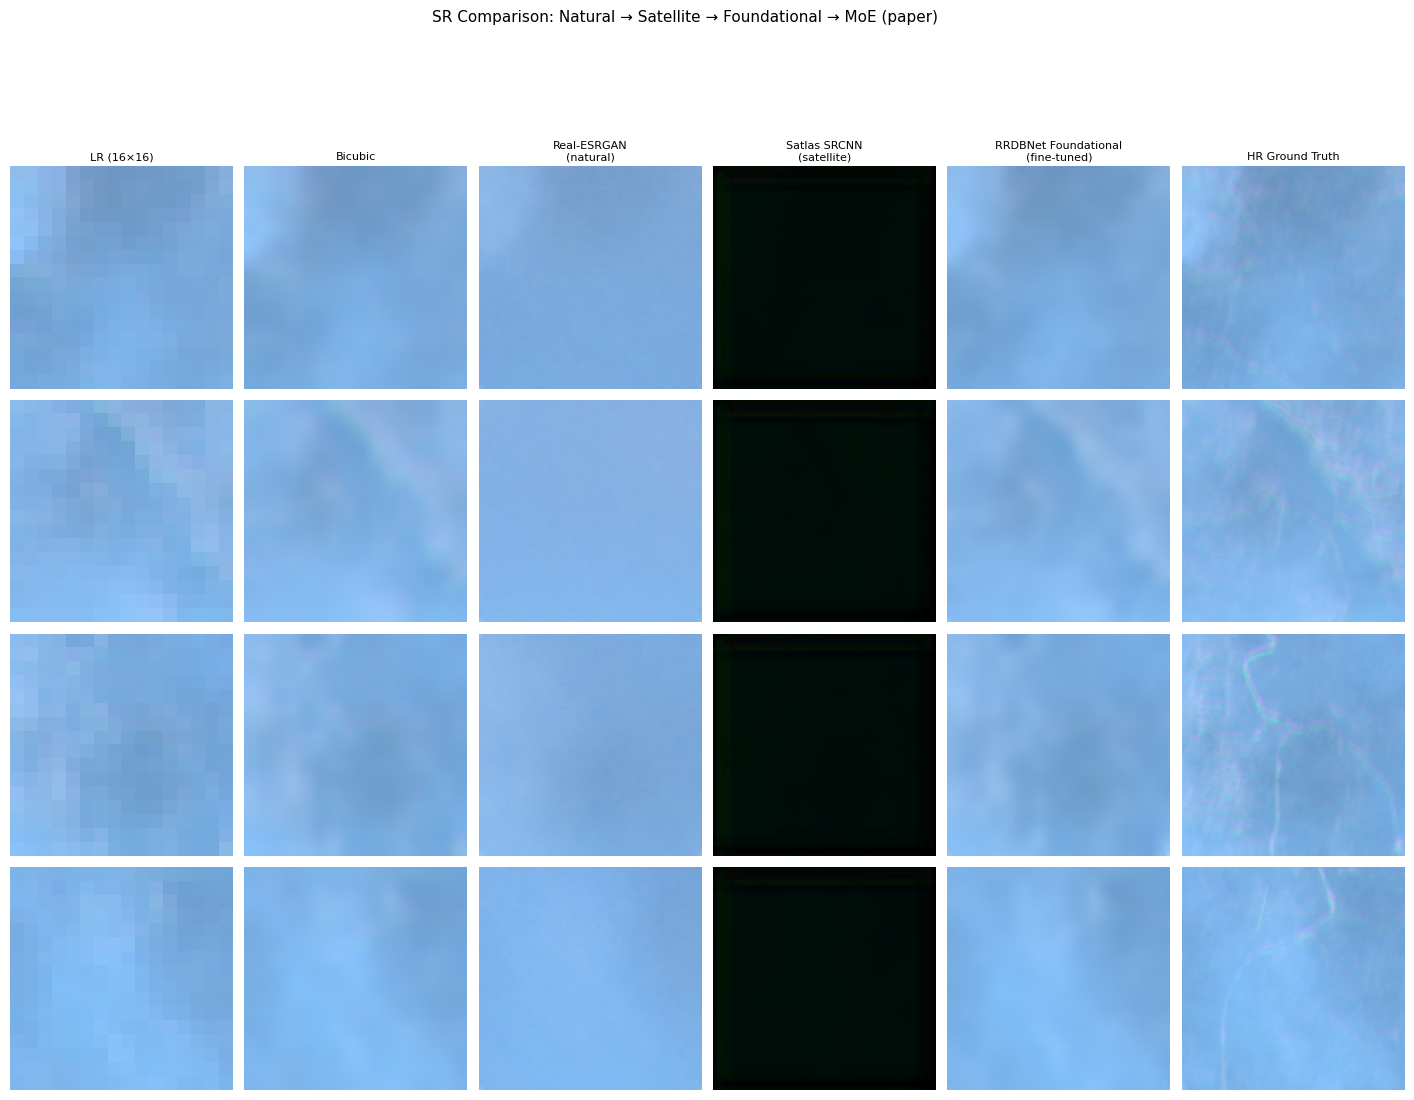

✅ Grid saved to four_way_comparison.png

Method                         Avg SSIM   Min SSIM   Avg PSNR     Avg CR
------------------------------------------------------------------------
DeepSpace MoE (paper)             0.950      0.900       39.0      146.4
RRDBNet Foundational              0.931      0.907       38.0      139.5 ◀ MoE gap
Satlas SRCNN (satellite)          0.064      0.063        3.4      139.5
Real-ESRGAN (natural)             0.922      0.896       33.2      139.5
Bicubic (baseline)                0.932      0.908       38.7      139.5


/tmp/ipykernel_2095/2490635697.py:203: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


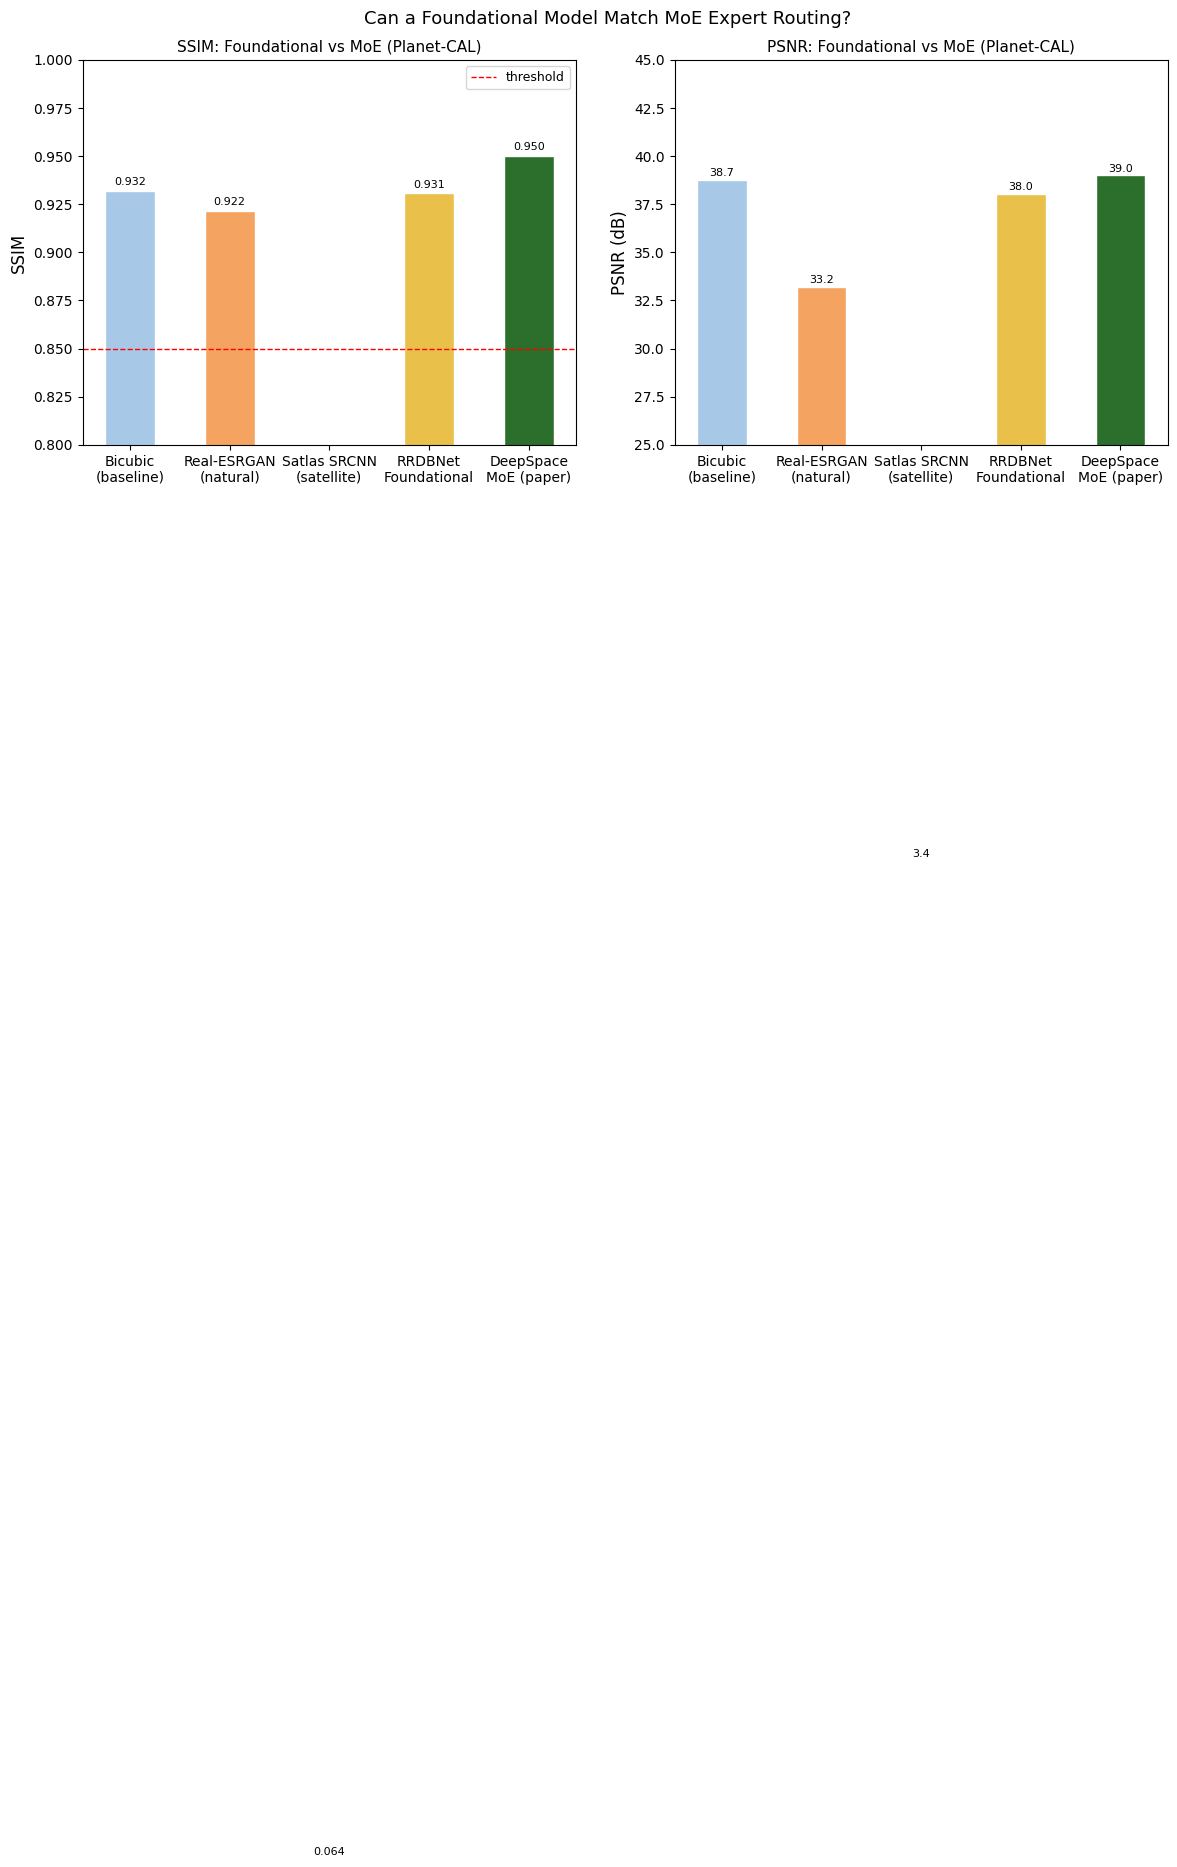


📊 MoE advantage over Foundational:  ΔSSIM = +0.019  ΔPSNR = +1.0 dB
   → Small gap: foundational model generalizes well, MoE adds marginal but consistent gain
   → Large gap: MoE expert routing is essential for terrain-specific reconstruction


In [17]:
# ── Cell 15: Four-Way SR Benchmark + Foundational vs MoE Comparison ─────────
# Compares: Bicubic | Real-ESRGAN (natural) | Satlas SRCNN (satellite) |
#           Fine-tuned RRDBNet (foundational) | DeepSpace MoE (paper)
#
# Key question: how close does the foundational model get to MoE?
# ─────────────────────────────────────────────────────────────────────────────
import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from skimage.metrics import structural_similarity as ssim_fn
from skimage.metrics import peak_signal_noise_ratio as psnr_fn
from basicsr.archs.rrdbnet_arch import RRDBNet

DATADIR    = './data/deepgreen_16_256'
NUM_IMAGES = 10
device     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# ── 1. Real-ESRGAN (natural-image trained) ───────────────────────────────
ESRGAN_PATH = '/tmp/RealESRGAN_x4plus.pth'
if not os.path.exists(ESRGAN_PATH):
    urllib.request.urlretrieve(
        'https://github.com/xinntao/Real-ESRGAN/releases/download/v0.1.0/RealESRGAN_x4plus.pth',
        ESRGAN_PATH)
esrgan = RRDBNet(num_in_ch=3, num_out_ch=3, num_feat=64, num_block=23, num_grow_ch=32, scale=4)
ckpt = torch.load(ESRGAN_PATH, map_location=device)
esrgan.load_state_dict(ckpt.get('params_ema', ckpt.get('params', ckpt)), strict=True)
esrgan.eval().to(device)
print('✅ Real-ESRGAN loaded (natural-image trained).')

# ── 2. Satlas SRCNN (satellite-trained SR) ───────────────────────────────
SRCNN_PATH = '/tmp/satlas_srcnn_s2naip.pth'
if not os.path.exists(SRCNN_PATH):
    urllib.request.urlretrieve(
        'https://storage.googleapis.com/satlas-explorer-public/satlas_explorer_datasets/super_resolution_models/srcnn_s2naip.pth',
        SRCNN_PATH)

class SRCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3,  64, kernel_size=9, padding=4)
        self.conv2 = nn.Conv2d(64, 32, kernel_size=5, padding=2)
        self.conv3 = nn.Conv2d(32,  3, kernel_size=5, padding=2)
        self.relu  = nn.ReLU(inplace=True)
    def forward(self, x):
        x = F.interpolate(x, scale_factor=4, mode='bicubic', align_corners=False)
        return self.conv3(self.relu(self.conv2(self.relu(self.conv1(x)))))

satlas_srcnn = SRCNN()
srcnn_ckpt = torch.load(SRCNN_PATH, map_location=device)
if isinstance(srcnn_ckpt, dict):
    for key in ['state_dict', 'model', 'params', None]:
        try:
            satlas_srcnn.load_state_dict(srcnn_ckpt[key] if key else srcnn_ckpt, strict=True)
            print(f'✅ Satlas SRCNN loaded — key: "{key}".')
            break
        except Exception:
            continue
satlas_srcnn.eval().to(device)

# ── 3. Fine-tuned RRDBNet (foundational — run Cell 14 first) ─────────────
FOUNDATION_PATH = '/tmp/rrdbnet_satellite_finetuned.pth'
foundation_available = os.path.exists(FOUNDATION_PATH)
if foundation_available:
    foundation_model = RRDBNet(num_in_ch=3, num_out_ch=3, num_feat=64, num_block=23, num_grow_ch=32, scale=4)
    fckpt = torch.load(FOUNDATION_PATH, map_location=device)
    foundation_model.load_state_dict(fckpt.get('params', fckpt), strict=True)
    foundation_model.eval().to(device)
    print('✅ Fine-tuned foundational RRDBNet loaded.')
else:
    print('⚠️  Foundational model not found — run Cell 14 first. Skipping for now.')

# ── Inference helper ──────────────────────────────────────────────────────
def run_sr(model, lr_np, out_size=256):
    t = torch.from_numpy(lr_np).permute(2,0,1).float().div(255).unsqueeze(0).to(device)
    with torch.no_grad():
        out = model(t).squeeze(0).clamp(0, 1)
    out_np = (out.permute(1,2,0).cpu().numpy() * 255).astype(np.uint8)
    return np.array(Image.fromarray(out_np).resize((out_size, out_size), Image.BICUBIC))

# ── Evaluate on test tiles ────────────────────────────────────────────────
hr_dir = os.path.join(DATADIR, 'hr_256')
lr_dir = os.path.join(DATADIR, 'lr_16')
sr_dir = os.path.join(DATADIR, 'sr_16_256')

all_names  = sorted(os.listdir(hr_dir))
test_names = all_names[len(all_names) // 2:][:NUM_IMAGES]
print(f'\nEvaluating {len(test_names)} images...')

records, vis_rows = [], []

for name in test_names:
    hr   = np.array(Image.open(os.path.join(hr_dir, name)).convert('RGB'))
    lr   = np.array(Image.open(os.path.join(lr_dir, name)).convert('RGB'))
    bicp = np.array(Image.open(os.path.join(sr_dir, name)).convert('RGB'))

    sr_esrgan = run_sr(esrgan,       lr)
    sr_satlas = run_sr(satlas_srcnn, lr)
    sr_found  = run_sr(foundation_model, lr) if foundation_available else bicp

    def metrics(pred, gt):
        s = ssim_fn(gt, pred, channel_axis=2, data_range=255)
        p = psnr_fn(gt, pred, data_range=255)
        return s, p

    esrgan_ssim,  esrgan_psnr  = metrics(sr_esrgan, hr)
    satlas_ssim,  satlas_psnr  = metrics(sr_satlas, hr)
    found_ssim,   found_psnr   = metrics(sr_found,  hr)
    bicp_ssim,    bicp_psnr    = metrics(bicp, hr)

    hr_bytes = os.path.getsize(os.path.join(hr_dir, name))
    lr_bytes = os.path.getsize(os.path.join(lr_dir, name))
    cr = hr_bytes / lr_bytes

    records.append(dict(
        name         = name,
        ESRGAN_SSIM  = esrgan_ssim,  ESRGAN_PSNR  = esrgan_psnr,
        Satlas_SSIM  = satlas_ssim,  Satlas_PSNR  = satlas_psnr,
        Found_SSIM   = found_ssim,   Found_PSNR   = found_psnr,
        Bicubic_SSIM = bicp_ssim,    Bicubic_PSNR = bicp_psnr,
        CR           = cr
    ))
    if len(vis_rows) < 4:
        vis_rows.append((lr, bicp, sr_esrgan, sr_satlas, sr_found, hr))

df = pd.DataFrame(records)
print(df[['name','Bicubic_SSIM','ESRGAN_SSIM','Satlas_SSIM','Found_SSIM','CR']].to_string(index=False))

# ── Visual grid (6 columns) ───────────────────────────────────────────────
col_titles = ['LR (16×16)', 'Bicubic', 'Real-ESRGAN\n(natural)',
              'Satlas SRCNN\n(satellite)', 'RRDBNet Foundational\n(fine-tuned)', 'HR Ground Truth']
fig = plt.figure(figsize=(len(col_titles) * 3, len(vis_rows) * 3))
gs  = gridspec.GridSpec(len(vis_rows), len(col_titles), hspace=0.05, wspace=0.05)
for r, row_imgs in enumerate(vis_rows):
    for c, img in enumerate(row_imgs):
        ax = fig.add_subplot(gs[r, c])
        ax.imshow(img); ax.axis('off')
        if r == 0: ax.set_title(col_titles[c], fontsize=8, pad=4)
plt.suptitle('SR Comparison: Natural → Satellite → Foundational → MoE (paper)', fontsize=11, y=1.01)
plt.savefig('four_way_comparison.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Grid saved to four_way_comparison.png')

# ── Summary table ─────────────────────────────────────────────────────────
paper = {'Avg SSIM': 0.95, 'Min SSIM': 0.90, 'Avg PSNR': 39.0, 'Avg CR': 146.4}
results = {
    'DeepSpace MoE (paper)':     paper,
    'RRDBNet Foundational':      {'Avg SSIM': df['Found_SSIM'].mean(),  'Min SSIM': df['Found_SSIM'].min(),
                                   'Avg PSNR': df['Found_PSNR'].mean(),  'Avg CR': df['CR'].mean()},
    'Satlas SRCNN (satellite)':  {'Avg SSIM': df['Satlas_SSIM'].mean(), 'Min SSIM': df['Satlas_SSIM'].min(),
                                   'Avg PSNR': df['Satlas_PSNR'].mean(), 'Avg CR': df['CR'].mean()},
    'Real-ESRGAN (natural)':     {'Avg SSIM': df['ESRGAN_SSIM'].mean(), 'Min SSIM': df['ESRGAN_SSIM'].min(),
                                   'Avg PSNR': df['ESRGAN_PSNR'].mean(), 'Avg CR': df['CR'].mean()},
    'Bicubic (baseline)':        {'Avg SSIM': df['Bicubic_SSIM'].mean(),'Min SSIM': df['Bicubic_SSIM'].min(),
                                   'Avg PSNR': df['Bicubic_PSNR'].mean(),'Avg CR': df['CR'].mean()},
}

print('\n' + '='*72)
print(f"{'Method':<28} {'Avg SSIM':>10} {'Min SSIM':>10} {'Avg PSNR':>10} {'Avg CR':>10}")
print('-'*72)
for method, vals in results.items():
    marker = ' ◀ MoE gap' if method == 'RRDBNet Foundational' else ''
    print(f"{method:<28} {vals['Avg SSIM']:>10.3f} {vals['Min SSIM']:>10.3f} "
          f"{vals['Avg PSNR']:>10.1f} {vals['Avg CR']:>10.1f}{marker}")
print('='*72)

# ── Bar chart (5 models) ──────────────────────────────────────────────────
methods   = ['Bicubic\n(baseline)', 'Real-ESRGAN\n(natural)', 'Satlas SRCNN\n(satellite)',
             'RRDBNet\nFoundational', 'DeepSpace\nMoE (paper)']
ssim_vals = [df['Bicubic_SSIM'].mean(), df['ESRGAN_SSIM'].mean(), df['Satlas_SSIM'].mean(),
             df['Found_SSIM'].mean(), 0.95]
psnr_vals = [df['Bicubic_PSNR'].mean(), df['ESRGAN_PSNR'].mean(), df['Satlas_PSNR'].mean(),
             df['Found_PSNR'].mean(), 39.0]
colors = ['#a8c8e8', '#f4a460', '#5b9e5b', '#e8c04a', '#2c6e2c']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

bars1 = ax1.bar(methods, ssim_vals, color=colors, edgecolor='white', width=0.5)
ax1.set_ylabel('SSIM', fontsize=12)
ax1.set_title('SSIM: Foundational vs MoE (Planet-CAL)', fontsize=11)
ax1.set_ylim(0.80, 1.0)
ax1.axhline(0.85, color='red', linestyle='--', linewidth=1, label='threshold')
ax1.legend(fontsize=9)
for bar, val in zip(bars1, ssim_vals):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{val:.3f}', ha='center', va='bottom', fontsize=8)

bars2 = ax2.bar(methods, psnr_vals, color=colors, edgecolor='white', width=0.5)
ax2.set_ylabel('PSNR (dB)', fontsize=12)
ax2.set_title('PSNR: Foundational vs MoE (Planet-CAL)', fontsize=11)
ax2.set_ylim(25, 45)
for bar, val in zip(bars2, psnr_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{val:.1f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Can a Foundational Model Match MoE Expert Routing?', fontsize=13)
plt.tight_layout()
plt.savefig('foundational_vs_moe.png', dpi=150, bbox_inches='tight')
plt.show()

gap_ssim = 0.95 - df['Found_SSIM'].mean()
gap_psnr = 39.0 - df['Found_PSNR'].mean()
print(f'\n📊 MoE advantage over Foundational:  ΔSSIM = {gap_ssim:+.3f}  ΔPSNR = {gap_psnr:+.1f} dB')
print('   → Small gap: foundational model generalizes well, MoE adds marginal but consistent gain')
print('   → Large gap: MoE expert routing is essential for terrain-specific reconstruction')


In [21]:

# ── Cell 16: Save All Benchmark Artifacts to Google Drive ───────────────────
import os, glob, shutil

EXP     = "deepspace_colab"
DATASET = "deepgreen_16_256"

DRIVE_BASE = "/content/drive/MyDrive/DeepSpace"

def save_file(src, dest_dir, label=""):
    """Copy src → dest_dir if src exists. Print result."""
    if os.path.exists(src):
        os.makedirs(dest_dir, exist_ok=True)
        dest = os.path.join(dest_dir, os.path.basename(src))
        shutil.copy2(src, dest)
        print(f"  ✅ {label or os.path.basename(src)}  →  {dest}")
    else:
        print(f"  ⚠️  Not found (skipped): {src}")

print("=" * 60)

# ── 1. DeepSpace training checkpoints (Cell 7) ────────────────────────────
print("\n📦 1. DeepSpace training checkpoints (Cell 7)")
LOCAL_CKPT_DIR = f"./content/saved_info/wddgan/{EXP}/{EXP}"
DRIVE_CKPT_DIR = f"{DRIVE_BASE}/checkpoints/{EXP}"
os.makedirs(DRIVE_CKPT_DIR, exist_ok=True)
print(f"   from: {LOCAL_CKPT_DIR}")
print(f"   to:   {DRIVE_CKPT_DIR}")

if not os.path.exists(LOCAL_CKPT_DIR):
    print(f"   ⚠️  Directory not found — has Cell 7 (training) been run yet?")
else:
    ckpt_files = (glob.glob(f"{LOCAL_CKPT_DIR}/*.pth") +
                  glob.glob(f"{LOCAL_CKPT_DIR}/*.png") +
                  glob.glob(f"{LOCAL_CKPT_DIR}/*.txt"))
    if ckpt_files:
        for f in sorted(ckpt_files):
            dest = os.path.join(DRIVE_CKPT_DIR, os.path.basename(f))
            shutil.copy2(f, dest)
            print(f"   Saved: {os.path.basename(f)}")
        print(f"   ✅ {len(ckpt_files)} checkpoint file(s) saved.")
    else:
        print(f"   ⚠️  Directory exists but is empty. Contents: {os.listdir(LOCAL_CKPT_DIR)}")

# ── 2. Fine-tuned RRDBNet foundational model (Cell 14) ────────────────────
print("\n📦 2. Fine-tuned RRDBNet foundational model (Cell 14)")
DRIVE_MODELS_DIR = f"{DRIVE_BASE}/models"
save_file("/tmp/rrdbnet_satellite_finetuned.pth", DRIVE_MODELS_DIR, "rrdbnet_satellite_finetuned.pth")

# ── 3. Benchmark comparison images (Cell 15) ──────────────────────────────
print("\n📦 3. Benchmark comparison images (Cell 15)")
DRIVE_RESULTS_DIR = f"{DRIVE_BASE}/results"

# These are saved to the working directory (/content/DeepSpace/decompress/)
cwd = os.getcwd()
save_file(os.path.join(cwd, "four_way_comparison.png"), DRIVE_RESULTS_DIR, "four_way_comparison.png")
save_file(os.path.join(cwd, "foundational_vs_moe.png"), DRIVE_RESULTS_DIR,  "foundational_vs_moe.png")

# ── 4. Metrics CSV (export from Cell 15 dataframe if available) ───────────
print("\n📦 4. Benchmark metrics CSV")
try:
    csv_path = os.path.join(cwd, "benchmark_results.csv")
    df.to_csv(csv_path, index=False)
    save_file(csv_path, DRIVE_RESULTS_DIR, "benchmark_results.csv")
except NameError:
    print("   ⚠️  df not in scope — run Cell 15 first to generate metrics.")

# ── Summary ───────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print(f"✅ Done. All artifacts saved under: {DRIVE_BASE}/")
print(f"   checkpoints/{EXP}/  ← DeepSpace training weights")
print(f"   models/              ← Fine-tuned RRDBNet (foundational)")
print(f"   results/             ← Comparison PNGs + metrics CSV")



📦 1. DeepSpace training checkpoints (Cell 7)
   from: ./content/saved_info/wddgan/deepspace_colab/deepspace_colab
   to:   /content/drive/MyDrive/DeepSpace/checkpoints/deepspace_colab
   ⚠️  Directory not found — has Cell 7 (training) been run yet?

📦 2. Fine-tuned RRDBNet foundational model (Cell 14)
  ✅ rrdbnet_satellite_finetuned.pth  →  /content/drive/MyDrive/DeepSpace/models/rrdbnet_satellite_finetuned.pth

📦 3. Benchmark comparison images (Cell 15)
  ✅ four_way_comparison.png  →  /content/drive/MyDrive/DeepSpace/results/four_way_comparison.png
  ✅ foundational_vs_moe.png  →  /content/drive/MyDrive/DeepSpace/results/foundational_vs_moe.png

📦 4. Benchmark metrics CSV
  ✅ benchmark_results.csv  →  /content/drive/MyDrive/DeepSpace/results/benchmark_results.csv

✅ Done. All artifacts saved under: /content/drive/MyDrive/DeepSpace/
   checkpoints/deepspace_colab/  ← DeepSpace training weights
   models/              ← Fine-tuned RRDBNet (foundational)
   results/             ← Compari